In [42]:
import torch
# import torch.nn as nn
import matplotlib.pyplot as plt

### Prepare dataset

In [ ]:
x_data = torch.tensor([[1.0], [2.0], [3.0]])
y_data = torch.tensor([[2.0], [4.0], [6.0]])

### Design model using Class
核心解析：self.linear = torch.nn.Linear(1, 1)

torch.nn.Linear(in_features, out_features) 是 PyTorch 封装的线性变换层，数学表达式为：y=xAT+b

- x：输入张量
- A：权重矩阵（形状：out_features × in_features）
- b：偏置向量（形状：out_features）
- y：输出张量

而 self.linear = torch.nn.Linear(1, 1) 表示：

- in_features=1：输入特征维度为 1（即输入是单个数值 / 形状为 (N,1) 的张量，N 是批量大小）
- out_features=1：输出特征维度为 1（输出也是单个数值 / 形状为 (N,1) 的张量）
- self.linear：将该线性层作为类的属性，方便后续前向传播时调用。

In [44]:
class LinearModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = torch.nn.Linear(1, 1)
        
    def forward(self, x):
        return self.linear(x)
model = LinearModel()

### 3. Construct Loss and Optimizer
使用 Pytorch API。构造损失函数和优化器

In [ ]:
criterion = torch.nn.MSELoss(size_average=False)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)


### 4. Training Cycle

In [ ]:
for epoch in range(1000):
    # 前馈
    y_pred = model(x_data)
    loss = criterion(y_pred, y_data)
    print(epoch, loss.item())
    
    # 反馈
    optimizer.zero_grad()
    loss.backward()
    
    # 更新
    optimizer.step()


In [ ]:
print('w=', model.linear.weight.item())
print('b=', model.linear.bias.item())
#test
x_test = torch.tensor([[4.0]])
y_test = model(x_test)
print("y_test=", y_test.item())


### 线性回归中不同优化器差异

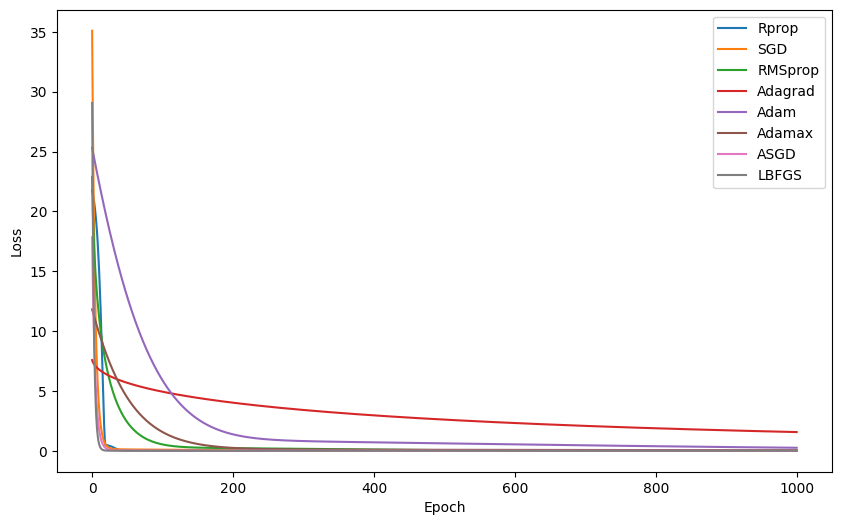

In [50]:
import torch
import matplotlib.pyplot as plt

class LinearModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = torch.nn.Linear(1, 1)
        
    def forward(self, x):
        return self.linear(x)


# 基础配置
epochNum = 1000
## 数据集
x_data = torch.tensor([[1.0], [2.0], [3.0]])
y_data = torch.tensor([[2.0], [4.0], [6.0]])
criterion = torch.nn.MSELoss()

# 定义所有要对比的优化器（名称 + 构造器）
optimizers = [
    ("Rprop", torch.optim.Rprop),
    ("SGD", torch.optim.SGD),
    ("RMSprop", torch.optim.RMSprop),
    ("Adagrad", torch.optim.Adagrad),
    ("Adam", torch.optim.Adam),
    ("Adamax", torch.optim.Adamax),
    ("ASGD", torch.optim.ASGD),
    ("LBFGS", torch.optim.LBFGS),
]

loss_records = {}  # 存储每个优化器的损失列表

for name, optim_cls in optimizers:
    # 🔴 关键：每次都重新初始化模型！保证起点一致
    model = LinearModel()  
    
    # 初始化当前优化器
    if name == "LBFGS":
        optimizer = optim_cls(model.parameters(), lr=0.01)
    else:
        optimizer = optim_cls(model.parameters(), lr=0.01)
    
    loss_list = []
    for epoch in range(epochNum):
        if name == "LBFGS":
            # LBFGS 需要 closure
            def closure():
                optimizer.zero_grad()
                y_pred = model(x_data)
                loss = criterion(y_pred, y_data)
                loss.backward()
                return loss
            loss = optimizer.step(closure)
        else:
            optimizer.zero_grad()
            y_pred = model(x_data)
            loss = criterion(y_pred, y_data)
            loss.backward()
            optimizer.step()
        
        loss_list.append(loss.item())
    
    loss_records[name] = loss_list

# 绘制对比曲线
plt.figure(figsize=(10, 6))
for name, loss_list in loss_records.items():
    plt.plot(range(epochNum), loss_list, label=name)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()